# NASDAQ Stage 2 Screener — Sector-Strength + Fundamentals Filtered

Screens NASDAQ-listed stocks for **Stage 2 / Minervini Trend Template** breakout setups,
filtered to stocks in the **hottest sectors**, with a **fundamentals overlay**
(EPS growth, sales growth, ROE, margins) and a **mid/large-cap filter**.

## Pipeline stages
```
Stage A  : Full NASDAQ ticker list          (~3,000+ tickers, 1 file download)
Stage B  : Bulk liquidity / price / cap     (~1 month batched data + market cap)
Stage B.5: Sector cache repair              (fixes Unknown rows before Stage C runs)
Stage C  : Sector classification + ranking  (3-tier: Wikipedia → yfinance fallback)
Stage D  : Minervini Trend Template         (8-point technical checklist)
Stage D2 : Fundamentals screen             (EPS/sales growth, ROE, margins)
Stage E  : Composite score + ranked output + charts
```

## Technical checklist (Stage D — Minervini Trend Template)
1. Price above 150-day and 200-day MA
2. 150-day MA above 200-day MA
3. 200-day MA trending up (slope check over last ~1 month)
4. 50-day MA above both 150-day and 200-day MA (stacked bullish)
5. Price ≥ 25% above 52-week low (Minervini threshold)
6. Price within 25% of 52-week high (Minervini threshold)
7. Relative strength vs NASDAQ positive over 3mo and 6mo
8. Volume on up-days > volume on down-days (last 60 sessions)

## Fundamentals checklist (Stage D2 — Minervini/CANSLIM-style)
9.  Quarterly EPS growth (YoY) ≥ 20%
10. Quarterly sales growth (YoY) ≥ 10%
11. Return on equity (ROE) ≥ 17%
12. Positive profit margin

## ⚠️ Caveats
- Watchlist generator only — not a buy signal.
- yfinance is unofficial and can break or rate-limit without warning.
- Run in your own Jupyter environment (needs internet access to Yahoo Finance).
- Always do your own due diligence before acting on screener output.


## 1. Setup & Configuration

All tunable parameters live here.

In [1]:

import pandas as pd
import numpy as np
import yfinance as yf
import requests
import time
import io
import os
from datetime import datetime
from concurrent.futures import ThreadPoolExecutor, TimeoutError as FuturesTimeoutError

pd.set_option('display.max_rows', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# ─────────────────────── CONFIG ───────────────────────────────────────────────
CONFIG = {
    # Stage B: liquidity filter
    "min_price":               5.0,
    "max_price":               2000.0,
    "min_avg_dollar_volume":   5_000_000,
    "bulk_lookback_days":      30,

    # Stage B: market cap (mid+large only)
    "min_market_cap":          2_000_000_000,   # $2B floor
    "max_market_cap":          None,             # no ceiling

    # Stage C: sector strength
    "top_n_sectors":           5,
    "sector_rs_lookback_days": 90,

    # Stage D: Minervini Trend Template (daily bars)
    "full_lookback_days":      400,
    "ma_slope_window":         20,
    "near_high_pct":           0.25,   # within 25% of 52w high
    "above_low_pct":           0.25,   # at least 25% above 52w low
    "rs_benchmark":            "^IXIC",

    # Stage D2: fundamentals thresholds
    "min_quarterly_eps_growth":   0.20,
    "min_quarterly_sales_growth": 0.10,
    "min_roe":                    0.17,
    "min_profit_margin":          0.0,
    "fundamentals_weight":        1.0,

    # Batching / rate-limit politeness
    "batch_size":       50,
    "batch_sleep_sec":  1.0,
    "max_retries":      3,

    # Set to e.g. 300 for a fast test run; None = full universe
    "max_universe_for_testing": None,
}

print("Config loaded.")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")


Config loaded.
  min_price: 5.0
  max_price: 2000.0
  min_avg_dollar_volume: 5000000
  bulk_lookback_days: 30
  min_market_cap: 2000000000
  max_market_cap: None
  top_n_sectors: 5
  sector_rs_lookback_days: 90
  full_lookback_days: 400
  ma_slope_window: 20
  near_high_pct: 0.25
  above_low_pct: 0.25
  rs_benchmark: ^IXIC
  min_quarterly_eps_growth: 0.2
  min_quarterly_sales_growth: 0.1
  min_roe: 0.17
  min_profit_margin: 0.0
  fundamentals_weight: 1.0
  batch_size: 50
  batch_sleep_sec: 1.0
  max_retries: 3
  max_universe_for_testing: None


## 2. Stage A — Build the NASDAQ Ticker Universe

Pull the official NASDAQ-listed symbol directory (one file, no per-ticker calls).
Falls back to the Wikipedia NASDAQ-100 list if the primary source is unreachable.


In [2]:

def get_nasdaq_universe():
    '''Pull full NASDAQ-listed symbol directory from Nasdaq Trader.'''
    url = "https://www.nasdaqtrader.com/dynamic/SymDir/nasdaqlisted.txt"
    headers = {"User-Agent": "Mozilla/5.0 (compatible; research-screener/1.0)"}
    resp = requests.get(url, headers=headers, timeout=15)
    resp.raise_for_status()
    lines = [l for l in resp.text.strip().split("\n")
             if not l.startswith("File Creation Time")]
    df = pd.read_csv(io.StringIO("\n".join(lines)), sep="|")
    df = df[(df["ETF"] == "N") & (df["Test Issue"] == "N")].copy()
    df = df[["Symbol", "Security Name"]].dropna()
    df = df[~df["Symbol"].str.contains(r"[\^\.\$]", regex=True, na=False)]
    return df.reset_index(drop=True)


def fallback_nasdaq100():
    '''Fallback: NASDAQ-100 constituents from Wikipedia.'''
    url = "https://en.wikipedia.org/wiki/Nasdaq-100"
    tables = pd.read_html(url)
    for t in tables:
        if "Ticker" in t.columns or "Symbol" in t.columns:
            col = "Ticker" if "Ticker" in t.columns else "Symbol"
            return t[[col]].rename(columns={col: "Symbol"})
    raise RuntimeError("Could not find ticker table on Wikipedia NASDAQ-100 page.")


try:
    universe_df = get_nasdaq_universe()
    print(f"✅ Full NASDAQ universe: {len(universe_df)} symbols")
except Exception as e:
    print(f"⚠️  Primary source failed ({e}). Falling back to NASDAQ-100.")
    universe_df = fallback_nasdaq100()
    print(f"✅ Fallback universe: {len(universe_df)} symbols")

if CONFIG["max_universe_for_testing"]:
    universe_df = universe_df.head(CONFIG["max_universe_for_testing"])
    print(f"(Testing mode: capped at {len(universe_df)} symbols)")

universe_df.head(10)


✅ Full NASDAQ universe: 4285 symbols


,Symbol,Security Name
0,AACB,Artius II Acquisition Inc. - Class A Ordinary ...
1,AACBR,Artius II Acquisition Inc. - Rights
2,AACBU,Artius II Acquisition Inc. - Units
3,AACG,ATA Creativity Global - American Depositary Sh...
4,AACI,Armada Acquisition Corp. III - Class A Ordinar...
5,AACIU,Armada Acquisition Corp. III - Units
6,AACIW,Armada Acquisition Corp. III - Warrant
7,AACO,Abony Acquisition Corp. I - Class A Ordinary S...
8,AACOU,Abony Acquisition Corp. I - Units
9,AACOW,Abony Acquisition Corp. I - Warrants


## 3. Stage B — Liquidity / Price / Market-Cap Filter

**Part 1:** pull ~1 month of batched daily data, drop penny stocks and illiquid names.  
**Part 2:** fetch market cap (via `fast_info`, timeout-protected) and keep mid+large cap only.

This typically cuts 3,000+ tickers to a few hundred before any expensive per-ticker calls.


In [3]:

def batch_download(tickers, period="1mo", interval="1d", config=CONFIG):
    '''Batch-download OHLCV for a list of tickers with retries and sleep between batches.'''
    all_data = {}
    batch_size = config["batch_size"]
    n_batches = (len(tickers) + batch_size - 1) // batch_size

    for i in range(0, len(tickers), batch_size):
        batch = tickers[i:i + batch_size]
        batch_num = i // batch_size + 1
        for attempt in range(config["max_retries"]):
            try:
                data = yf.download(
                    batch, period=period, interval=interval,
                    group_by="ticker", auto_adjust=True,
                    progress=False, threads=True,
                )
                break
            except Exception as e:
                print(f"  Batch {batch_num}/{n_batches} attempt {attempt+1} failed: {e}")
                time.sleep(2 * (attempt + 1))
        else:
            print(f"  ⚠️ Batch {batch_num}/{n_batches} failed after retries.")
            continue

        for t in batch:
            try:
                df_t = data if len(batch) == 1 else (
                    data[t] if t in data.columns.get_level_values(0) else None
                )
                if df_t is not None and not df_t.dropna(how="all").empty:
                    all_data[t] = df_t.dropna(how="all")
            except Exception:
                continue

        print(f"  Batch {batch_num}/{n_batches} done ({len(batch)} tickers).")
        time.sleep(config["batch_sleep_sec"])

    return all_data


def cheap_liquidity_filter(universe_df, config=CONFIG):
    '''Stage B part 1: price + dollar-volume filter via 1-month batched data.'''
    tickers = universe_df["Symbol"].tolist()
    print(f"Pulling {config['bulk_lookback_days']}d data for {len(tickers)} tickers...")
    raw = batch_download(tickers, period=f"{config['bulk_lookback_days']}d")

    survivors, rows = [], []
    for t, df in raw.items():
        if df is None or df.empty or "Close" not in df.columns:
            continue
        last_price    = df["Close"].dropna().iloc[-1] if not df["Close"].dropna().empty else np.nan
        avg_dollar_vol = (df["Close"] * df["Volume"]).mean()
        if pd.isna(last_price) or pd.isna(avg_dollar_vol):
            continue
        passes = (config["min_price"] <= last_price <= config["max_price"]
                  and avg_dollar_vol >= config["min_avg_dollar_volume"])
        rows.append({"Symbol": t, "Last Price": last_price,
                     "Avg Dollar Volume (1mo)": avg_dollar_vol, "Passed": passes})
        if passes:
            survivors.append(t)

    print(f"✅ Liquidity filter: {len(survivors)} / {len(tickers)} passed.")
    return survivors, pd.DataFrame(rows)


def _get_market_cap_timeout(ticker, timeout_sec=8):
    '''Fetch market cap with hard timeout — fast_info first, .info fallback.'''
    for fn in (
        lambda _t=ticker: yf.Ticker(_t).fast_info.get("marketCap", np.nan),
        lambda _t=ticker: yf.Ticker(_t).info.get("marketCap", np.nan),
    ):
        ex = ThreadPoolExecutor(max_workers=1)
        future = ex.submit(fn)
        ex.shutdown(wait=False)
        try:
            cap = future.result(timeout=timeout_sec)
            if cap and not (isinstance(cap, float) and np.isnan(cap)):
                return cap
        except (FuturesTimeoutError, Exception):
            pass
    return np.nan


def market_cap_filter(tickers, config=CONFIG):
    '''Stage B part 2: market-cap filter (mid+large cap only).'''
    rows, survivors = [], []
    print(f"Fetching market cap for {len(tickers)} liquidity survivors...")
    for i, t in enumerate(tickers):
        market_cap = _get_market_cap_timeout(t)
        min_cap = config["min_market_cap"] or 0
        max_cap = config["max_market_cap"] or np.inf
        passes  = pd.notna(market_cap) and (min_cap <= market_cap <= max_cap)
        rows.append({"Symbol": t, "Market Cap": market_cap, "Passed": passes})
        if passes:
            survivors.append(t)
        cap_str = f"${market_cap:,.0f}" if pd.notna(market_cap) else "n/a"
        print(f"  [{i+1}/{len(tickers)}] {'✓' if passes else '–'} {t}: {cap_str}      ", end="\r")
        time.sleep(0.3)
    cap_df = pd.DataFrame(rows)
    print(f"\n✅ Market cap filter: {len(survivors)} / {len(tickers)} are mid/large cap.")
    return survivors, cap_df


# ── Run Stage B ───────────────────────────────────────────────────────────────
stage_b_liquidity_survivors, stage_b_stats = cheap_liquidity_filter(universe_df)
stage_b_stats.sort_values("Avg Dollar Volume (1mo)", ascending=False).head(20)


Pulling 30d data for 4285 tickers...
  Batch 1/86 done (50 tickers).
  Batch 2/86 done (50 tickers).
  Batch 3/86 done (50 tickers).
  Batch 4/86 done (50 tickers).
  Batch 5/86 done (50 tickers).
  Batch 6/86 done (50 tickers).
  Batch 7/86 done (50 tickers).
  Batch 8/86 done (50 tickers).
  Batch 9/86 done (50 tickers).
  Batch 10/86 done (50 tickers).
  Batch 11/86 done (50 tickers).
  Batch 12/86 done (50 tickers).
  Batch 13/86 done (50 tickers).
  Batch 14/86 done (50 tickers).
  Batch 15/86 done (50 tickers).
  Batch 16/86 done (50 tickers).
  Batch 17/86 done (50 tickers).
  Batch 18/86 done (50 tickers).


$COLA: possibly delisted; no price data found  (period=30d)

1 Failed download:
['COLA']: possibly delisted; no price data found  (period=30d)


  Batch 19/86 done (50 tickers).
  Batch 20/86 done (50 tickers).
  Batch 21/86 done (50 tickers).
  Batch 22/86 done (50 tickers).
  Batch 23/86 done (50 tickers).
  Batch 24/86 done (50 tickers).
  Batch 25/86 done (50 tickers).
  Batch 26/86 done (50 tickers).
  Batch 27/86 done (50 tickers).


$FBYDP: possibly delisted; no price data found  (period=30d)

1 Failed download:
['FBYDP']: possibly delisted; no price data found  (period=30d)


  Batch 28/86 done (50 tickers).
  Batch 29/86 done (50 tickers).
  Batch 30/86 done (50 tickers).
  Batch 31/86 done (50 tickers).
  Batch 32/86 done (50 tickers).
  Batch 33/86 done (50 tickers).
  Batch 34/86 done (50 tickers).


...

$UCFIW: possibly delisted; no price data found  (period=30d)

1 Failed download:
['UCFIW']: possibly delisted; no price data found  (period=30d)


  Batch 79/86 done (50 tickers).


$VCRE: possibly delisted; no price data found  (period=30d)

1 Failed download:
['VCRE']: possibly delisted; no price data found  (period=30d)


  Batch 80/86 done (50 tickers).
  Batch 81/86 done (50 tickers).
  Batch 82/86 done (50 tickers).
  Batch 83/86 done (50 tickers).
  Batch 84/86 done (50 tickers).
  Batch 85/86 done (50 tickers).
  Batch 86/86 done (35 tickers).
✅ Liquidity filter: 1353 / 4285 passed.


,Symbol,Last Price,Avg Dollar Volume (1mo),Passed
2572,MU,975.56,"57,120,630,038.76",True
2760,NVDA,194.83,"35,184,033,259.09",True
3598,SPCX,162.00,"29,213,459,616.29",True
3562,SNDK,"1,745.00","21,213,189,418.36",True
3881,TSLA,393.45,"19,266,726,128.55",True
19,AAPL,308.63,"18,491,473,229.30",True
2555,MSFT,390.49,"18,211,249,946.10",True
2548,MRVL,245.29,"16,472,318,460.71",True
234,AMD,517.82,"16,224,334,856.47",True
1977,INTC,120.35,"15,475,098,703.65",True


In [4]:

stage_b_survivors, market_cap_stats = market_cap_filter(stage_b_liquidity_survivors)
market_cap_stats.sort_values("Market Cap", ascending=False).head(20)


Fetching market cap for 1353 liquidity survivors...
  [608/1353] ✓ INDV: $4,704,542,393           

$INHD: possibly delisted; no price data found  (period=5d)


  [647/1353] ✓ JD: $35,950,311,133         

$JDZG: possibly delisted; no price data found  (period=5d)


  [1353/1353] – ZYME: $1,935,730,454          
✅ Market cap filter: 794 / 1353 are mid/large cap.


,Symbol,Market Cap,Passed
853,NVDA,"4,718,977,474,349.98",True
3,AAPL,"4,532,958,753,995.61",True
518,GOOGL,"4,391,828,139,545.55",True
517,GOOG,"4,346,312,407,712.91",True
798,MSFT,"2,900,729,395,021.65",True
83,AMZN,"2,610,427,727,137.26",True
1124,SPCX,"2,134,218,342,276.00",True
139,AVGO,"1,714,869,840,445.03",True
758,META,"1,479,647,005,874.83",True
1222,TSLA,"1,477,689,602,891.19",True


## 3.5 Stage B.5 — Sector Cache Repair

If you have an existing `sector_cache.csv` with many `"Unknown"` rows (caused by yfinance
rate-limiting mid-loop), run this cell **once** to repair it before Stage C.

It re-classifies only the unknown rows using the same 3-tier approach as Stage C:
Wikipedia S&P 500 → Wikipedia NASDAQ-100 → yfinance with timeout.
Already-classified rows are left untouched.

**Skip this cell if your cache is clean, or if you have no cache yet.**


In [7]:

# ── GICS (Wikipedia) → Yahoo Finance sector name normalisation ────────────────
GICS_TO_YAHOO = {
    "Information Technology": "Technology",
    "Financials":             "Financial Services",
    "Consumer Discretionary": "Consumer Cyclical",
    "Consumer Staples":       "Consumer Defensive",
    "Health Care":            "Healthcare",
    "Communication Services": "Communication Services",
    "Industrials":            "Industrials",
    "Materials":              "Basic Materials",
    "Real Estate":            "Real Estate",
    "Energy":                 "Energy",
    "Utilities":              "Utilities",
}

GICS_INDUSTRY_TO_YAHOO = {
    "Semiconductors":                             "Semiconductors",
    "Semiconductor Equipment":                    "Semiconductor Equipment & Materials",
    "Systems Software":                           "Software—Infrastructure",
    "Application Software":                       "Software—Application",
    "Internet Services & Infrastructure":         "Software—Infrastructure",
    "Interactive Media & Services":               "Internet Content & Information",
    "Technology Hardware, Storage & Peripherals": "Computer Hardware",
    "Biotechnology":                              "Biotechnology",
    "Pharmaceuticals":                            "Drug Manufacturers—General",
    "Health Care Equipment":                      "Medical Devices",
    "Managed Health Care":                        "Healthcare Plans",
    "Restaurants":                                "Restaurants",
    "Automobile Manufacturers":                   "Auto Manufacturers",
    "Broadline Retail":                           "Discount Stores",
    "Specialty Retail":                           "Specialty Retail",
    "Electric Utilities":                         "Utilities—Regulated Electric",
    "Integrated Telecommunication Services":      "Telecom Services",
    "Wireless Telecommunication Services":        "Telecom Services",
    "Oil, Gas & Consumable Fuels":                "Oil & Gas E&P",
    "Investment Banking & Brokerage":             "Capital Markets",
    "Consumer Finance":                           "Credit Services",
}

def _normalise_gics(gics_sector, gics_industry):
    return (GICS_TO_YAHOO.get(gics_sector, gics_sector),
            GICS_INDUSTRY_TO_YAHOO.get(gics_industry, gics_industry))


def _build_wikipedia_sector_map():
    '''One bulk fetch each from Wikipedia S&P500 and NASDAQ-100. No per-ticker calls.'''
    mapping = {}
    sources = [
        ("S&P 500",
         "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies",
         "Symbol", "GICS Sector", "GICS Sub-Industry"),
        ("NASDAQ-100",
         "https://en.wikipedia.org/wiki/Nasdaq-100",
         "Ticker", "GICS Sector", "GICS Sub-Industry"),
    ]
    for name, url, sym_col, sec_col, ind_col in sources:
        try:
            tables = pd.read_html(url)
            df = next((t for t in tables
                       if sym_col in t.columns and sec_col in t.columns), None)
            if df is None:
                print(f"  ⚠️  {name}: columns not found — skipping")
                continue
            for _, row in df.iterrows():
                sym = str(row[sym_col]).strip().replace(".", "-")
                gs  = str(row.get(sec_col, "Unknown")).strip()
                gi  = str(row.get(ind_col, "Unknown")).strip()
                if sym and gs not in ("nan", "", "Unknown"):
                    mapping[sym] = _normalise_gics(gs, gi)
            print(f"  ✓ {name}: {len(df)} tickers")
        except Exception as e:
            print(f"  ⚠️  {name} failed: {e}")
    return mapping


def _yf_info_timeout(ticker, timeout_sec=8):
    '''yfinance .info with hard timeout — shutdown(wait=False) so hung calls never block.'''
    ex = ThreadPoolExecutor(max_workers=1, thread_name_prefix="yf_repair")
    future = ex.submit(lambda _t=ticker: yf.Ticker(_t).info)
    ex.shutdown(wait=False)
    try:
        info = future.result(timeout=timeout_sec)
        return info.get("sector", "Unknown") or "Unknown", \
               info.get("industry", "Unknown") or "Unknown"
    except FuturesTimeoutError:
        return "Timeout", "Timeout"
    except Exception:
        return "Unknown", "Unknown"


def repair_sector_cache(cache_path="sector_cache.csv", timeout_sec=8, checkpoint_every=25):
    '''
    Re-classifies Unknown/Timeout rows in an existing sector_cache.csv.
    Safe to run repeatedly — known rows are never modified.
    '''
    if not os.path.exists(cache_path):
        print(f"No cache found at {cache_path} — nothing to repair (Stage C will build it fresh).")
        return

    df = pd.read_csv(cache_path)
    bad_vals = ["Unknown", "Timeout", "nan", ""]
    bad_mask = df["Sector"].isin(bad_vals) | df["Sector"].isna()
    print(f"Cache: {len(df)} rows — {(~bad_mask).sum()} classified, {bad_mask.sum()} unknown")

    if bad_mask.sum() == 0:
        print("✅ Cache is clean — nothing to repair.")
        return

    to_fix = df[bad_mask]["Symbol"].tolist()

    # Tier 1+2: Wikipedia
    print("\nTier 1+2: Wikipedia bulk fetch...")
    wiki_map   = _build_wikipedia_sector_map()
    wiki_fixed = 0
    still_bad  = []

    for sym in to_fix:
        if sym in wiki_map:
            sector, industry = wiki_map[sym]
            df.loc[df["Symbol"] == sym, "Sector"]   = sector
            df.loc[df["Symbol"] == sym, "Industry"] = industry
            wiki_fixed += 1
        else:
            still_bad.append(sym)

    print(f"  Wikipedia fixed {wiki_fixed} / {len(to_fix)}")
    if wiki_fixed:
        df.to_csv(cache_path, index=False)
        print(f"  💾 Saved")

    # Tier 3: yfinance residual
    if still_bad:
        print(f"\nTier 3: yfinance for {len(still_bad)} remaining tickers...")
        yf_fixed = timeouts = 0
        for i, sym in enumerate(still_bad):
            sector, industry = _yf_info_timeout(sym, timeout_sec)
            if sector == "Timeout":
                timeouts += 1
                print(f"  [{i+1}/{len(still_bad)}] ⏱  {sym} timed out")
            elif sector not in bad_vals:
                yf_fixed += 1
                print(f"  [{i+1}/{len(still_bad)}] ✓ {sym}: {sector}          ", end="\r")
            else:
                print(f"  [{i+1}/{len(still_bad)}] – {sym}: still unknown     ", end="\r")

            df.loc[df["Symbol"] == sym, "Sector"]   = sector
            df.loc[df["Symbol"] == sym, "Industry"] = industry

            if (i + 1) % checkpoint_every == 0:
                df.to_csv(cache_path, index=False)
                print(f"\n  💾 Checkpoint ({i+1}/{len(still_bad)})")
            time.sleep(0.4)

        df.to_csv(cache_path, index=False)
        print(f"\n  yfinance: fixed={yf_fixed} | timeouts={timeouts} | "
              f"still unknown={len(still_bad)-yf_fixed-timeouts}")

    # Summary
    df_out = pd.read_csv(cache_path)
    final_bad  = df_out["Sector"].isin(bad_vals).sum()
    print(f"\n{'='*50}")
    print(f"Repair complete — classified: {len(df_out)-final_bad} | unknown: {final_bad}")
    print(df_out[df_out['Sector'] != 'Unknown']['Sector'].value_counts().to_string())


# ── Run repair (safe to skip if cache doesn't exist yet) ─────────────────────
repair_sector_cache()


No cache found at sector_cache.csv — nothing to repair (Stage C will build it fresh).


## 4. Stage C — Sector Classification & Strength Ranking

**3-tier sector lookup** — most reliable first, most expensive last:
- **Tier 1:** Wikipedia S&P 500 (one bulk request, GICS sector, ~500 stocks)
- **Tier 2:** Wikipedia NASDAQ-100 (one bulk request, ~100 stocks)
- **Tier 3:** yfinance `.info` with hard timeout (residual only — small set)

Results cached to `sector_cache.csv`. Repeated runs skip the fetch entirely.


In [8]:
!pip install lxml==6.0.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 27.9 MB/s  0:00:00


In [9]:

SECTOR_CACHE_PATH = "sector_cache.csv"


def _save_cache(cache, path):
    pd.DataFrame.from_dict(cache, orient="index") \
      .rename_axis("Symbol").to_csv(path)


def _fetch_sector_yf_timeout(ticker, timeout_sec=8):
    '''yfinance .info per-ticker fallback with hard timeout.'''
    ex = ThreadPoolExecutor(max_workers=1, thread_name_prefix="yf_sector")
    future = ex.submit(lambda _t=ticker: yf.Ticker(_t).info)
    ex.shutdown(wait=False)
    try:
        info = future.result(timeout=timeout_sec)
        return (info.get("sector",   "Unknown") or "Unknown",
                info.get("industry", "Unknown") or "Unknown")
    except FuturesTimeoutError:
        return "Timeout", "Timeout"
    except Exception:
        return "Unknown", "Unknown"


def get_sector_map(tickers, cache_path=SECTOR_CACHE_PATH, timeout_sec=8, checkpoint_every=25):
    '''
    3-tier sector lookup with CSV caching.
      Tier 1: Wikipedia S&P 500  (bulk, free, reliable)
      Tier 2: Wikipedia NASDAQ-100 (bulk, free, reliable)
      Tier 3: yfinance .info with per-call timeout (residual only)
    '''
    # Load cache
    if os.path.exists(cache_path):
        cache = pd.read_csv(cache_path).set_index("Symbol").to_dict("index")
        print(f"Loaded {len(cache)} cached entries")
    else:
        cache = {}

    to_classify = [t for t in tickers if t not in cache]
    print(f"Cache hits: {len(tickers)-len(to_classify)} | To classify: {len(to_classify)}")

    if not to_classify:
        results = {t: cache.get(t, {"Sector": "Unknown", "Industry": "Unknown"}) for t in tickers}
        return pd.DataFrame.from_dict(results, orient="index").reset_index() \
                 .rename(columns={"index": "Symbol"})

    # Tier 1+2: Wikipedia
    print("\nTier 1+2: Wikipedia bulk fetch...")
    wiki_map = _build_wikipedia_sector_map()   # defined in Stage B.5 repair cell above
    print(f"  Wikipedia coverage: {len(wiki_map)} tickers\n")

    still_needed = []
    for t in to_classify:
        if t in wiki_map:
            sector, industry = wiki_map[t]
            cache[t] = {"Sector": sector, "Industry": industry}
        else:
            still_needed.append(t)

    wiki_hits = len(to_classify) - len(still_needed)
    print(f"  ✓ Wikipedia covered {wiki_hits}/{len(to_classify)}")
    print(f"  Tier 3 needed for {len(still_needed)} remaining")
    if wiki_hits:
        _save_cache(cache, cache_path)

    # Tier 3: yfinance residual
    if still_needed:
        print(f"\nTier 3: yfinance for {len(still_needed)} tickers...")
        timeouts = 0
        for i, t in enumerate(still_needed):
            sector, industry = _fetch_sector_yf_timeout(t, timeout_sec)
            if sector == "Timeout":
                timeouts += 1
                print(f"  [{i+1}/{len(still_needed)}] ⏱  {t} timed out")
            else:
                print(f"  [{i+1}/{len(still_needed)}] {'✓' if sector != 'Unknown' else '–'} "
                      f"{t}: {sector}          ", end="\r")
            cache[t] = {"Sector": sector, "Industry": industry}
            if (i + 1) % checkpoint_every == 0:
                _save_cache(cache, cache_path)
                print(f"\n  💾 Checkpoint ({i+1}/{len(still_needed)})")
            time.sleep(0.3)
        _save_cache(cache, cache_path)
        print(f"\n  Done. Timeouts: {timeouts}/{len(still_needed)}")

    _save_cache(cache, cache_path)
    results = {t: cache.get(t, {"Sector": "Unknown", "Industry": "Unknown"}) for t in tickers}
    df = pd.DataFrame.from_dict(results, orient="index").reset_index() \
           .rename(columns={"index": "Symbol"})
    print(f"\n✅ Stage C: {len(df[~df['Sector'].isin(['Unknown','Timeout'])])} tickers classified")
    return df


sector_df = get_sector_map(stage_b_survivors)
sector_df = sector_df[~sector_df["Sector"].isin(["Unknown", "Timeout"])]
print(f"\nSector breakdown ({len(sector_df)} tickers):")
print(sector_df["Sector"].value_counts().to_string())
sector_df.head(10)


Cache hits: 0 | To classify: 794

Tier 1+2: Wikipedia bulk fetch...
  ⚠️  S&P 500 failed: HTTP Error 403: Forbidden
  ⚠️  NASDAQ-100 failed: HTTP Error 403: Forbidden
  Wikipedia coverage: 0 tickers

  ✓ Wikipedia covered 0/794
  Tier 3 needed for 794 remaining

Tier 3: yfinance for 794 tickers...
  [25/794] ✓ AFRM: Financial Services          
  💾 Checkpoint (25/794)
  [50/794] ✓ APA: Energy          ive          
  💾 Checkpoint (50/794)
  [75/794] ✓ AVGO: Technology                      
  💾 Checkpoint (75/794)
  [100/794] ✓ BLLN: Healthcare                      
  💾 Checkpoint (100/794)
  [125/794] ✓ CATY: Financial Services            
  💾 Checkpoint (125/794)
  [150/794] ✓ CHYM: Technology          es          
  💾 Checkpoint (150/794)
  [175/794] ✓ CPRT: Industrials                      
  💾 Checkpoint (175/794)
  [200/794] ✓ DFTX: Healthcare                  
  💾 Checkpoint (200/794)
  [225/794] ✓ EBC: Financial Services              
  💾 Checkpoint (225/794)
  [250/794] ✓ EXPO:

,Symbol,Sector,Industry
0,AAL,Industrials,Airlines
1,AAOI,Technology,Communication Equipment
2,AAON,Industrials,Building Products & Equipment
3,AAPL,Technology,Consumer Electronics
4,ABCL,Healthcare,Biotechnology
5,ABNB,Consumer Cyclical,Travel Services
6,ABVX,Healthcare,Biotechnology
7,ACAD,Healthcare,Biotechnology
8,ACGL,Financial Services,Insurance - Diversified
9,ACHC,Healthcare,Medical Care Facilities


In [10]:

def rank_sector_strength(sector_df, config=CONFIG):
    '''Rank sectors by median stock RS vs the NASDAQ Composite.'''
    lookback  = config["sector_rs_lookback_days"]
    benchmark = config["rs_benchmark"]

    price_data = batch_download(sector_df["Symbol"].tolist(),
                                period=f"{lookback+10}d", interval="1d")
    bench_raw  = yf.download(benchmark, period=f"{lookback+10}d",
                              interval="1d", auto_adjust=True, progress=False)["Close"]
    bench_close = bench_raw.iloc[:, 0] if isinstance(bench_raw, pd.DataFrame) else bench_raw

    bench_ret_val = bench_close.iloc[-1] / bench_close.iloc[0] - 1
    bench_ret = bench_ret_val.item() if hasattr(bench_ret_val, "item") else float(bench_ret_val)

    returns = {}
    for t, df in price_data.items():
        closes = df["Close"].dropna()
        if len(closes) >= 2:
            returns[t] = closes.iloc[-1] / closes.iloc[0] - 1

    ret_df = pd.DataFrame(list(returns.items()), columns=["Symbol", f"Return_{lookback}d"])
    merged = sector_df.merge(ret_df, on="Symbol", how="inner")

    sector_strength = (
        merged.groupby("Sector")[f"Return_{lookback}d"]
        .median().reset_index()
        .rename(columns={f"Return_{lookback}d": "Median Stock Return"})
    )
    sector_strength["Benchmark Return"] = bench_ret
    sector_strength["Relative Strength"] = (
        sector_strength["Median Stock Return"] - sector_strength["Benchmark Return"]
    )
    return sector_strength.sort_values("Relative Strength", ascending=False).reset_index(drop=True), merged


sector_strength, merged_with_returns = rank_sector_strength(sector_df)
print("Sector strength ranking (vs NASDAQ Composite):\n")
sector_strength


  Batch 1/16 done (50 tickers).
  Batch 2/16 done (50 tickers).
  Batch 3/16 done (50 tickers).
  Batch 4/16 done (50 tickers).
  Batch 5/16 done (50 tickers).
  Batch 6/16 done (50 tickers).
  Batch 7/16 done (50 tickers).
  Batch 8/16 done (50 tickers).
  Batch 9/16 done (50 tickers).
  Batch 10/16 done (50 tickers).
  Batch 11/16 done (50 tickers).
  Batch 12/16 done (50 tickers).
  Batch 13/16 done (50 tickers).
  Batch 14/16 done (50 tickers).
  Batch 15/16 done (50 tickers).
  Batch 16/16 done (42 tickers).
Sector strength ranking (vs NASDAQ Composite):



,Sector,Median Stock Return,Benchmark Return,Relative Strength
0,Healthcare,0.18,0.11,0.07
1,Technology,0.17,0.11,0.05
2,Energy,0.09,0.11,-0.02
3,Utilities,0.09,0.11,-0.02
4,Real Estate,0.09,0.11,-0.03
5,Financial Services,0.08,0.11,-0.03
6,Industrials,0.07,0.11,-0.04
7,Consumer Defensive,0.04,0.11,-0.07
8,Consumer Cyclical,0.03,0.11,-0.08
9,Communication Services,0.02,0.11,-0.09


In [11]:

top_sectors = sector_strength.head(CONFIG["top_n_sectors"])["Sector"].tolist()
print(f"🔥 Top {CONFIG['top_n_sectors']} hottest sectors: {top_sectors}\n")

stage_c_survivors = merged_with_returns[
    merged_with_returns["Sector"].isin(top_sectors)
]["Symbol"].tolist()
print(f"✅ Stage C: {len(stage_c_survivors)} tickers in top sectors.")


🔥 Top 5 hottest sectors: ['Healthcare', 'Technology', 'Energy', 'Utilities', 'Real Estate']

✅ Stage C: 442 tickers in top sectors.


## 5. Stage D — Minervini Trend Template (Technical Screen)

Full 8-point technical checklist run only on Stage C survivors (~50–150 tickers).


In [12]:

def compute_stage2_metrics(df, benchmark_series, config=CONFIG):
    '''Minervini Trend Template — 8 technical criteria. Returns dict or None.'''
    df = df.dropna(subset=["Close", "Volume"]).copy()
    if len(df) < 260:
        return None

    close = df["Close"]
    ma50  = close.rolling(50).mean()
    ma150 = close.rolling(150).mean()
    ma200 = close.rolling(200).mean()

    last_close = close.iloc[-1]
    lma50, lma150, lma200 = ma50.iloc[-1], ma150.iloc[-1], ma200.iloc[-1]
    if pd.isna(lma200):
        return None

    # 1: price above 150d and 200d MA
    price_above_mas = last_close > lma150 and last_close > lma200
    # 2: 150d MA above 200d MA
    ma150_above_ma200 = lma150 > lma200
    # 3: 200d MA trending up
    ma200_then = ma200.iloc[-config["ma_slope_window"]]
    ma200_slope = (lma200 / ma200_then - 1) if pd.notna(ma200_then) and ma200_then != 0 else np.nan
    ma200_rising = ma200_slope > 0 if pd.notna(ma200_slope) else False
    # 4: 50d MA stacked above both
    stacked = lma50 > lma150 and lma50 > lma200
    # 5: price >= 25% above 52w low
    low_52w  = close.iloc[-252:].min() if len(close) >= 252 else close.min()
    pct_above_low = (last_close - low_52w) / low_52w if low_52w > 0 else np.nan
    above_low_ok  = pct_above_low >= config["above_low_pct"] if pd.notna(pct_above_low) else False
    # 6: price within 25% of 52w high
    high_52w = close.iloc[-252:].max() if len(close) >= 252 else close.max()
    pct_below_high = (high_52w - last_close) / high_52w if high_52w > 0 else np.nan
    near_high = pct_below_high <= config["near_high_pct"] if pd.notna(pct_below_high) else False
    # 7: RS vs benchmark positive 3mo + 6mo
    def ret_over(series, days):
        if len(series) <= days:
            return np.nan
        v1 = series.iloc[-1];    v1 = v1.item() if hasattr(v1, "item") else float(v1)
        v0 = series.iloc[-days]; v0 = v0.item() if hasattr(v0, "item") else float(v0)
        return (v1 / v0 - 1) if v0 != 0 else np.nan

    rs_3m = ret_over(close, 63)  - ret_over(benchmark_series, 63)
    rs_6m = ret_over(close, 126) - ret_over(benchmark_series, 126)
    rs_positive = (rs_3m > 0 and rs_6m > 0) if pd.notna(rs_3m) and pd.notna(rs_6m) else False
    # 8: volume up-days > down-days
    rec = df.iloc[-60:]
    avg_up   = rec[rec["Close"].diff() > 0]["Volume"].mean()
    avg_down = rec[rec["Close"].diff() < 0]["Volume"].mean()
    vol_ok   = (avg_up > avg_down) if pd.notna(avg_up) and pd.notna(avg_down) else False

    return {
        "Last Close": last_close, "MA50": lma50, "MA150": lma150, "MA200": lma200,
        "Price Above MAs": price_above_mas, "MA150 Above MA200": ma150_above_ma200,
        "200d MA Rising": ma200_rising, "200d MA Slope %": ma200_slope,
        "MAs Stacked Bullish": stacked,
        "Above 52w Low (25%+)": above_low_ok, "Pct Above 52w Low": pct_above_low,
        "Near 52w High": near_high, "Pct Below 52w High": pct_below_high,
        "RS Positive": rs_positive, "RS vs NASDAQ (3mo)": rs_3m, "RS vs NASDAQ (6mo)": rs_6m,
        "Volume Confirms Uptrend": vol_ok, "52w High": high_52w, "52w Low": low_52w,
    }


def run_stage2_screen(tickers, config=CONFIG):
    print(f"Pulling {config['full_lookback_days']}d history for {len(tickers)} survivors...")
    price_data = batch_download(tickers, period=f"{config['full_lookback_days']}d")

    bench_raw = yf.download(config["rs_benchmark"], period=f"{config['full_lookback_days']}d",
                             interval="1d", auto_adjust=True, progress=False)["Close"]
    bench = bench_raw.iloc[:, 0] if isinstance(bench_raw, pd.DataFrame) else bench_raw

    rows = []
    for t, df in price_data.items():
        m = compute_stage2_metrics(df, bench, config)
        if m:
            m["Symbol"] = t
            rows.append(m)

    print(f"✅ Stage D: metrics computed for {len(rows)} tickers.")
    return pd.DataFrame(rows)


stage_d_results = run_stage2_screen(stage_c_survivors)
stage_d_results.head(10)


Pulling 400d history for 442 survivors...
  Batch 1/9 done (50 tickers).
  Batch 2/9 done (50 tickers).
  Batch 3/9 done (50 tickers).
  Batch 4/9 done (50 tickers).
  Batch 5/9 done (50 tickers).
  Batch 6/9 done (50 tickers).
  Batch 7/9 done (50 tickers).
  Batch 8/9 done (50 tickers).
  Batch 9/9 done (42 tickers).
✅ Stage D: metrics computed for 421 tickers.


,Last Close,MA50,MA150,MA200,Price Above MAs,MA150 Above MA200,200d MA Rising,200d MA Slope %,MAs Stacked Bullish,Above 52w Low (25%+),Pct Above 52w Low,Near 52w High,Pct Below 52w High,RS Positive,RS vs NASDAQ (3mo),RS vs NASDAQ (6mo),Volume Confirms Uptrend,52w High,52w Low,Symbol
0,120.95,168.66,100.07,82.23,True,True,True,0.19,True,True,5.21,False,0.46,False,-0.02,2.36,True,223.10,19.49,AAOI
1,308.63,293.46,273.90,270.32,True,True,True,0.02,True,True,0.53,True,0.02,True,0.03,0.03,True,315.20,201.58,AAPL
2,8.11,5.35,4.19,4.38,True,False,True,0.04,True,True,1.92,True,0.00,True,1.12,1.26,True,8.12,2.78,ABCL
3,144.65,112.33,117.56,112.02,True,True,True,0.02,False,True,17.66,True,0.00,False,0.04,-0.04,False,145.31,7.75,ABVX
4,25.97,22.14,23.59,23.27,True,True,False,-0.01,False,True,0.29,True,0.07,False,-0.01,-0.14,True,28.06,20.06,ACAD
5,31.91,25.77,20.88,21.13,True,False,True,0.02,True,True,1.73,True,0.00,True,0.15,1.14,True,31.91,11.68,ACHC
6,54.88,44.29,43.66,45.19,True,False,False,-0.01,False,True,0.43,True,0.00,True,0.15,0.04,True,54.88,38.47,ACIW
7,144.50,159.38,113.62,106.70,True,True,True,0.09,True,True,1.13,True,0.25,True,0.34,0.69,True,191.60,67.69,ACLS
8,97.77,78.87,58.46,53.13,True,True,True,0.14,True,True,3.09,True,0.23,True,1.23,1.37,True,126.89,23.92,ACMR
9,219.72,234.92,270.61,288.68,False,False,False,-0.04,False,False,0.14,False,0.43,False,-0.28,-0.48,False,382.24,193.41,ADBE


## 6. Stage D2 — Fundamentals Screen (Minervini/CANSLIM-style)

Runs only on Stage D survivors (~few dozen). Each `.info` call is timeout-protected.

- EPS growth (YoY) ≥ 20% — strong earnings momentum
- Sales growth (YoY) ≥ 10% — confirms genuine demand growth
- ROE ≥ 17% — Minervini's quality-of-business threshold
- Positive profit margin — basic profitability check


In [13]:

def fundamentals_screen(tickers, config=CONFIG, timeout_sec=8):
    '''Minervini/CANSLIM fundamentals — runs only on the small Stage D survivor set.'''
    rows = []
    print(f"Fetching fundamentals for {len(tickers)} Stage D survivors...")

    for i, t in enumerate(tickers):
        info = {}
        ex = ThreadPoolExecutor(max_workers=1)
        future = ex.submit(lambda _t=t: yf.Ticker(_t).info)
        ex.shutdown(wait=False)
        try:
            info = future.result(timeout=timeout_sec)
        except (FuturesTimeoutError, Exception):
            print(f"  [{i+1}/{len(tickers)}] ⏱  {t} timed out")

        eps    = info.get("earningsQuarterlyGrowth", np.nan)
        sales  = info.get("revenueGrowth",           np.nan)
        roe    = info.get("returnOnEquity",           np.nan)
        margin = info.get("profitMargins",            np.nan)

        eps_ok    = pd.notna(eps)    and eps    >= config["min_quarterly_eps_growth"]
        sales_ok  = pd.notna(sales)  and sales  >= config["min_quarterly_sales_growth"]
        roe_ok    = pd.notna(roe)    and roe    >= config["min_roe"]
        margin_ok = pd.notna(margin) and margin >  config["min_profit_margin"]

        score = sum([eps_ok, sales_ok, roe_ok, margin_ok])
        print(f"  [{i+1}/{len(tickers)}] {t}: EPS={eps_ok} Sales={sales_ok} "
              f"ROE={roe_ok} Margin={margin_ok} → {score}/4", end="\r")

        rows.append({
            "Symbol": t,
            "Quarterly EPS Growth YoY": eps,  "EPS Growth OK":  eps_ok,
            "Quarterly Sales Growth YoY": sales, "Sales Growth OK": sales_ok,
            "ROE": roe,    "ROE OK":    roe_ok,
            "Profit Margin": margin, "Profitable": margin_ok,
        })
        time.sleep(0.3)

    fund_df = pd.DataFrame(rows)
    fund_df["Fundamentals Score"] = fund_df[
        ["EPS Growth OK", "Sales Growth OK", "ROE OK", "Profitable"]
    ].sum(axis=1)
    print(f"\n✅ Stage D2: fundamentals scored for {len(fund_df)} tickers.")
    return fund_df


fundamentals_df = fundamentals_screen(stage_d_results["Symbol"].tolist())
fundamentals_df.sort_values("Fundamentals Score", ascending=False).head(20)


Fetching fundamentals for 421 Stage D survivors...
  [408/421] ⏱  VTRS timed outales=False ROE=False Margin=False → 0/4
  [409/421] ⏱  WAY timed outSales=False ROE=False Margin=False → 0/4
  [421/421] ZS: EPS=False Sales=True ROE=False Margin=False → 1/40/4
✅ Stage D2: fundamentals scored for 421 tickers.


,Symbol,Quarterly EPS Growth YoY,EPS Growth OK,Quarterly Sales Growth YoY,Sales Growth OK,ROE,ROE OK,Profit Margin,Profitable,Fundamentals Score
397,VICR,7.14,True,0.20,True,0.20,True,0.32,True,4
31,AMAT,0.31,True,0.11,True,0.40,True,0.29,True,4
386,TXN,0.31,True,0.19,True,0.32,True,0.29,True,4
22,ALAB,1.52,True,0.93,True,0.21,True,0.27,True,4
372,TER,3.03,True,0.87,True,0.29,True,0.23,True,4
41,APPF,0.35,True,0.20,True,0.33,True,0.15,True,4
51,AUPH,0.47,True,0.24,True,0.65,True,1.00,True,4
52,AVGO,0.88,True,0.48,True,0.37,True,0.39,True,4
343,SIMO,2.43,True,1.05,True,0.20,True,0.16,True,4
362,STX,1.20,True,0.44,True,17.88,True,0.22,True,4


## 7. Stage E — Composite Scoring & Final Ranked Watchlist

**Technical score** (0–8, Minervini Trend Template) + **Fundamentals score** (0–4)  
= **Composite score** (max 12), ranked best to worst.

**This is a watchlist to research further — not a buy list.**


In [14]:

def score_and_rank(stage_d_results, fundamentals_df, sector_df, market_cap_stats, config=CONFIG):
    tech_cols  = ["Price Above MAs", "MA150 Above MA200", "200d MA Rising",
                  "MAs Stacked Bullish", "Above 52w Low (25%+)", "Near 52w High",
                  "RS Positive", "Volume Confirms Uptrend"]
    fund_cols  = ["EPS Growth OK", "Sales Growth OK", "ROE OK", "Profitable"]

    df = stage_d_results.copy()
    df["Technical Score"]    = df[tech_cols].sum(axis=1)
    df = df.merge(fundamentals_df, on="Symbol", how="left")
    df["Fundamentals Score"] = df["Fundamentals Score"].fillna(0)
    df["Composite Score"]    = df["Technical Score"] + config["fundamentals_weight"] * df["Fundamentals Score"]
    df["Max Score"]          = 8 + config["fundamentals_weight"] * 4

    df = df.merge(sector_df[["Symbol","Sector","Industry"]], on="Symbol", how="left")
    df = df.merge(market_cap_stats[["Symbol","Market Cap"]],  on="Symbol", how="left")

    cols = (["Symbol","Sector","Industry","Market Cap","Composite Score","Max Score",
              "Technical Score","Fundamentals Score","Last Close"]
            + tech_cols + fund_cols
            + ["200d MA Slope %","RS vs NASDAQ (3mo)","RS vs NASDAQ (6mo)",
               "Pct Below 52w High","Pct Above 52w Low",
               "Quarterly EPS Growth YoY","Quarterly Sales Growth YoY","ROE","Profit Margin",
               "MA50","MA150","MA200","52w High","52w Low"])
    df = df[[c for c in cols if c in df.columns]]
    return df.sort_values(["Composite Score","RS vs NASDAQ (3mo)"], ascending=False).reset_index(drop=True)


final_watchlist = score_and_rank(stage_d_results, fundamentals_df, sector_df, market_cap_stats)

threshold = final_watchlist["Max Score"].iloc[0] * 0.75 if len(final_watchlist) else 9
top_candidates = final_watchlist[final_watchlist["Composite Score"] >= threshold]
print(f"🎯 {len(top_candidates)} stocks scored ≥ {threshold:.1f} / "
      f"{final_watchlist['Max Score'].iloc[0] if len(final_watchlist) else 12:.1f}:\n")
top_candidates


🎯 125 stocks scored ≥ 9.0 / 12.0:



,Symbol,Sector,Industry,Market Cap,Composite Score,Max Score,Technical Score,Fundamentals Score,Last Close,Price Above MAs,...,Pct Above 52w Low,Quarterly EPS Growth YoY,Quarterly Sales Growth YoY,ROE,Profit Margin,MA50,MA150,MA200,52w High,52w Low
0,ALAB,Technology,Semiconductors,"69,663,616,870.00",12.00,12.00,8,4,406.42,True,...,3.59,1.52,0.93,0.21,0.27,304.07,199.76,195.68,483.02,88.57
1,SIMO,Technology,Semiconductors,"10,196,424,773.11",12.00,12.00,8,4,300.71,True,...,3.30,2.43,1.05,0.20,0.16,263.69,163.85,145.85,336.90,69.89
2,CRDO,Technology,Semiconductors,"45,110,868,988.08",12.00,12.00,8,4,241.91,True,...,1.75,3.62,1.57,0.34,0.35,217.35,160.76,158.72,302.52,87.81
3,DAVE,Technology,Software - Application,"4,924,990,531.68",12.00,12.00,8,4,387.36,True,...,1.48,1.01,0.47,1.12,0.37,279.86,226.50,224.76,387.36,155.92
4,STX,Technology,Computer Hardware,"185,562,929,382.45",12.00,12.00,8,4,820.16,True,...,4.82,1.20,0.44,17.88,0.22,839.69,528.11,455.89,"1,093.26",140.85
5,FTNT,Technology,Software - Infrastructure,"114,476,311,093.75",12.00,12.00,8,4,156.25,True,...,1.10,0.23,0.20,1.32,0.27,126.81,96.34,93.15,158.98,74.39
6,LRCX,Technology,Semiconductor Equipment & Materials,"439,451,914,569.61",12.00,12.00,8,4,351.41,True,...,2.73,0.37,0.24,0.67,0.31,320.92,248.57,222.49,433.33,94.32
7,TGTX,Healthcare,Biotechnology,"8,160,885,860.03",12.00,12.00,8,4,53.31,True,...,1.02,2.91,0.70,1.13,0.66,43.23,34.94,34.65,55.83,26.39
8,TXN,Technology,Semiconductors,"266,729,982,965.80",12.00,12.00,8,4,293.08,True,...,0.93,0.31,0.19,0.32,0.29,295.58,229.21,213.94,332.28,151.57
9,KRYS,Healthcare,Biotechnology,"11,056,972,298.84",12.00,12.00,8,4,375.07,True,...,1.78,0.56,0.32,0.20,0.54,311.01,276.04,253.90,378.15,134.94


In [15]:

# Full ranked watchlist
final_watchlist


,Symbol,Sector,Industry,Market Cap,Composite Score,Max Score,Technical Score,Fundamentals Score,Last Close,Price Above MAs,...,Pct Above 52w Low,Quarterly EPS Growth YoY,Quarterly Sales Growth YoY,ROE,Profit Margin,MA50,MA150,MA200,52w High,52w Low
0,ALAB,Technology,Semiconductors,"69,663,616,870.00",12.00,12.00,8,4,406.42,True,...,3.59,1.52,0.93,0.21,0.27,304.07,199.76,195.68,483.02,88.57
1,SIMO,Technology,Semiconductors,"10,196,424,773.11",12.00,12.00,8,4,300.71,True,...,3.30,2.43,1.05,0.20,0.16,263.69,163.85,145.85,336.90,69.89
2,CRDO,Technology,Semiconductors,"45,110,868,988.08",12.00,12.00,8,4,241.91,True,...,1.75,3.62,1.57,0.34,0.35,217.35,160.76,158.72,302.52,87.81
3,DAVE,Technology,Software - Application,"4,924,990,531.68",12.00,12.00,8,4,387.36,True,...,1.48,1.01,0.47,1.12,0.37,279.86,226.50,224.76,387.36,155.92
4,STX,Technology,Computer Hardware,"185,562,929,382.45",12.00,12.00,8,4,820.16,True,...,4.82,1.20,0.44,17.88,0.22,839.69,528.11,455.89,"1,093.26",140.85
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
416,DOX,Technology,Software - Infrastructure,"5,493,987,000.00",1.00,12.00,0,1,51.75,False,...,0.05,-0.16,0.04,0.16,0.12,59.09,67.69,70.67,89.62,49.32
417,INSM,Healthcare,Biotechnology,"24,189,573,200.86",1.00,12.00,0,1,111.60,False,...,0.21,NaN,2.30,-2.94,-1.44,111.50,146.01,151.76,211.41,91.88
418,CTSH,Technology,Information Technology Services,"19,861,270,793.91",1.00,12.00,0,1,41.99,False,...,0.08,-0.00,0.06,0.15,0.10,49.84,64.57,65.57,85.66,38.73
419,WIX,Technology,Software - Infrastructure,"2,065,273,303.99",1.00,12.00,0,1,49.35,False,...,0.22,NaN,0.14,NaN,-0.02,57.96,77.18,93.74,184.24,40.43


## 8. Quick Visual Check — Top Candidates

Daily close with 50/150/200-day MAs for the top-scoring setups.

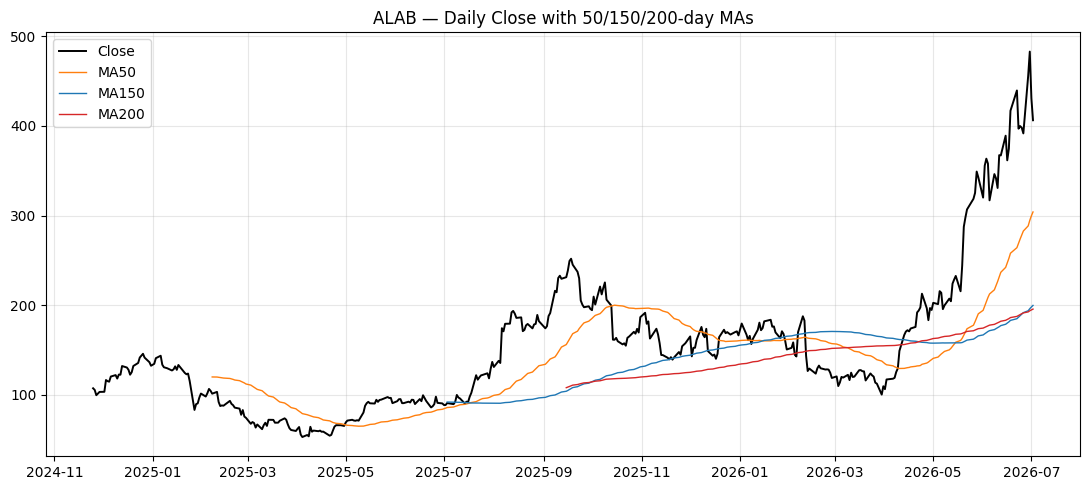

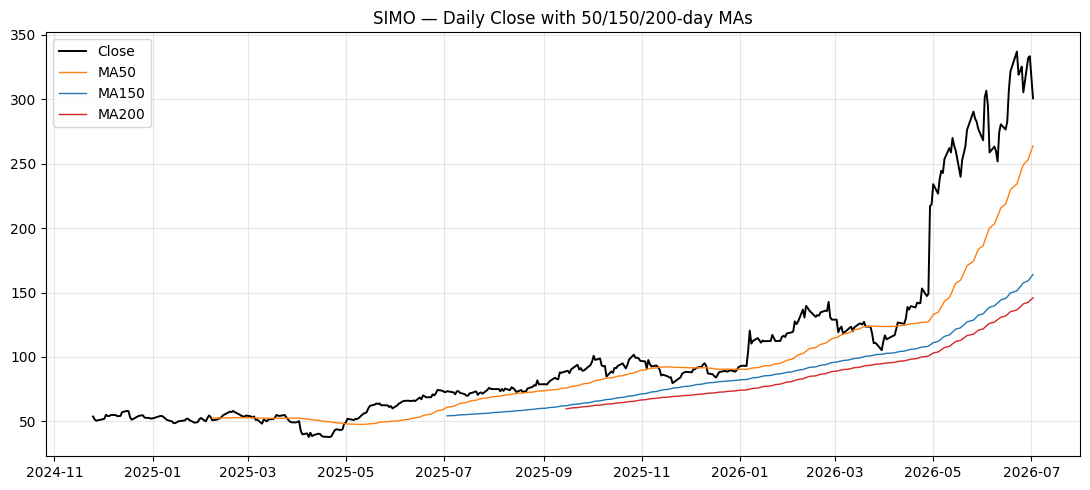

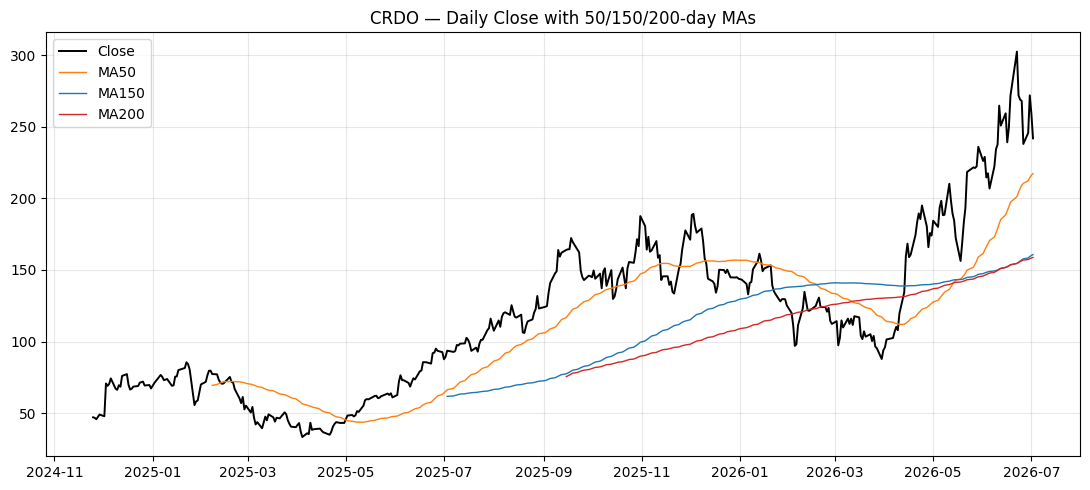

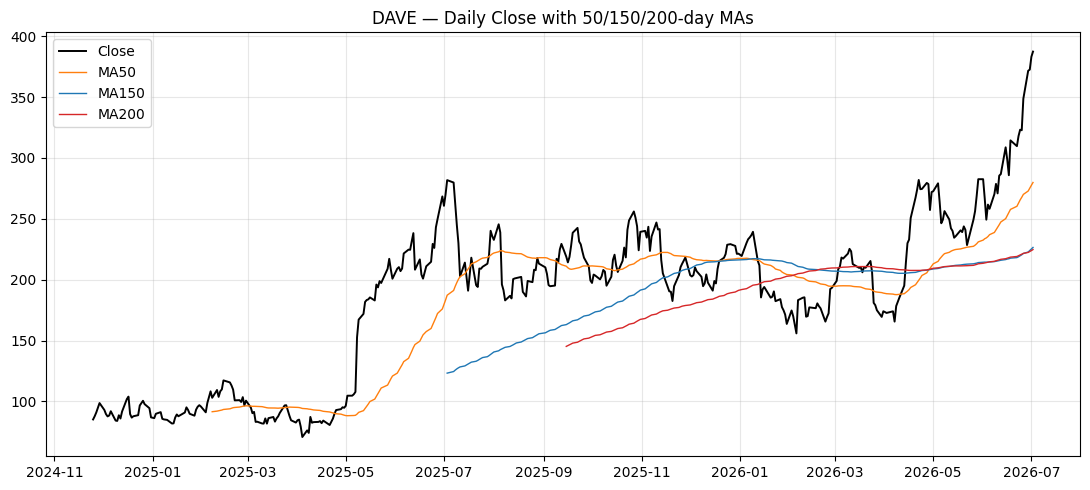

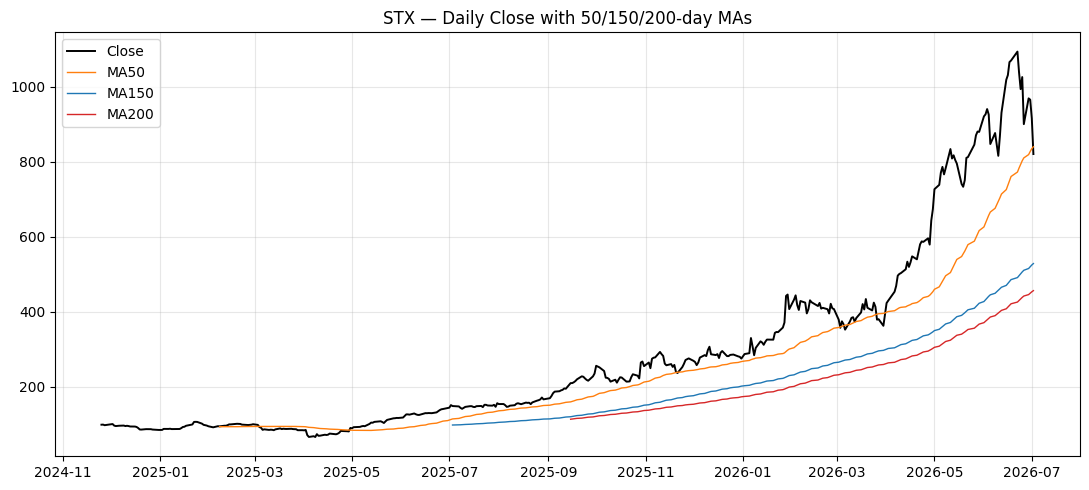

In [16]:

import matplotlib.pyplot as plt

def plot_candidate(ticker, config=CONFIG):
    df = yf.download(ticker, period=f"{config['full_lookback_days']}d",
                      interval="1d", auto_adjust=True, progress=False)
    if df.empty:
        print(f"No data for {ticker}")
        return
    close = df["Close"]
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(close.index, close,                   label="Close", linewidth=1.4, color="black")
    ax.plot(close.index, close.rolling(50).mean(), label="MA50",  linewidth=1,   color="tab:orange")
    ax.plot(close.index, close.rolling(150).mean(),label="MA150", linewidth=1,   color="tab:blue")
    ax.plot(close.index, close.rolling(200).mean(),label="MA200", linewidth=1,   color="tab:red")
    ax.set_title(f"{ticker} — Daily Close with 50/150/200-day MAs")
    ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


for sym in top_candidates["Symbol"].head(5):
    plot_candidate(sym)


## 9. Export Results

In [ ]:

output_path = f"stage2_watchlist_{datetime.now().strftime('%Y%m%d')}.csv"
final_watchlist.to_csv(output_path, index=False)
print(f"Saved: {output_path}")


## 10. Notes & Next Steps

- **Stage B.5 (cache repair)** — run once if your `sector_cache.csv` has Unknown rows.
  Safe to skip if the cache is clean or doesn't exist yet.
- **Tune `CONFIG`** — `near_high_pct`, `above_low_pct`, `min_market_cap`,
  `top_n_sectors`, `min_quarterly_eps_growth` are the most impactful knobs.
- **`fundamentals_weight`** — set to `0` to rank on technicals only (fundamentals still shown);
  raise above `1.0` to weight fundamentals more heavily than technicals.
- **Scheduling** — convert to a scheduled job via `papermill` + cron, or
  `jupyter nbconvert --to script` + cron. Happy to help when ready.
- **Rate limits** — if batches keep failing, increase `batch_sleep_sec` or decrease `batch_size`.
- **Data quality** — yfinance fundamentals fields are sometimes missing for smaller/newer names.
  Always verify against the company's actual filings before acting on anything here.
